In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [64]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_customer_data_custom_ratios.csv to ecommerce_customer_data_custom_ratios (2).csv


In [69]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

In [70]:
df.shape

(250000, 13)

In [71]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [74]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [75]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0


In [76]:
df.duplicated().sum()

np.int64(0)

Data Cleaning

In [77]:
df.dropna(inplace=True)

In [78]:
df.drop_duplicates(inplace=True)
df['Purchase Date']=pd.to_datetime(df['Purchase Date'])


In [79]:
df['Total Purchase Amount']=df['Quantity']*df['Product Price']
df['Month']= df['Purchase Date'].dt.month
df['Day']= df['Purchase Date'].dt.day_name()

In [97]:
snapshot_date=df['Purchase Date'].max()+pd.Timedelta(days=1)
rfm=df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date-x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns=['Recency','Frequency','Monetary']
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
1                 58          1       845
2                299          2       678
3                 89          7      4591
4                586          1       276
5                171          6      3976


In [100]:
rfm['R_score']=pd.qcut(rfm['Recency'],4,labels=[4,3,2,1])
rfm['F_score']=pd.qcut(rfm['Frequency'].rank(method='first'),4,labels=[1,2,3,4])
rfm['M_score']=pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4])


In [109]:
def segment(row):
  if row['R_score']== 4:
    return 'Active'
  elif row['R_score']>=2:
    return 'Potential Churn'
  else:
    return 'Churn Risk'

rfm['Segment']=rfm.apply(segment,axis=1)

In [83]:
rfm['Segment'].value_counts()

,count
Segment,
Active,49139


In [84]:
X = rfm[['Recency','Frequency','Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [85]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster']= kmeans.fit_predict(X_scaled)


In [108]:
print(rfm.columns)

Index(['Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score'], dtype='object')


Visualize Purchase Pattern

Top Customers by Spending

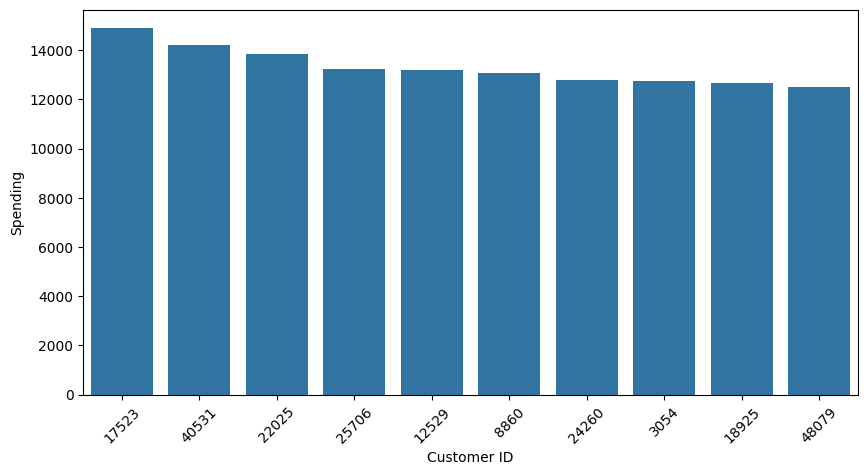

In [118]:
top = rfm.sort_values('Monetary',ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top.index.astype(str),y=top['Monetary'])
plt.xlabel('Customer ID')
plt.ylabel('Spending')
plt.xticks(rotation=45)
plt.show()

Monthly Sales Trend


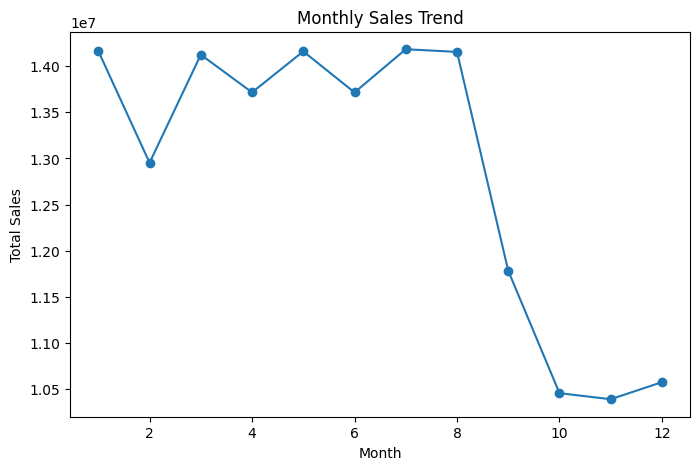

In [119]:
monthly=df.groupby('Month')['Total Purchase Amount'].sum()
plt.figure(figsize=(8,5))
monthly.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

Customer Segment


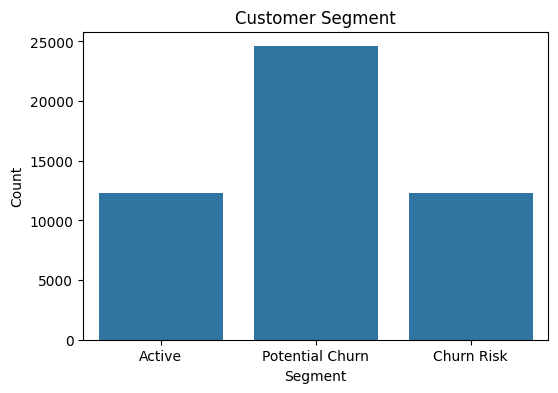

In [120]:
plt.figure(figsize=(6,4))
sns.countplot(x='Segment',data=rfm)
plt.title('Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.show()

Revenue by Segment

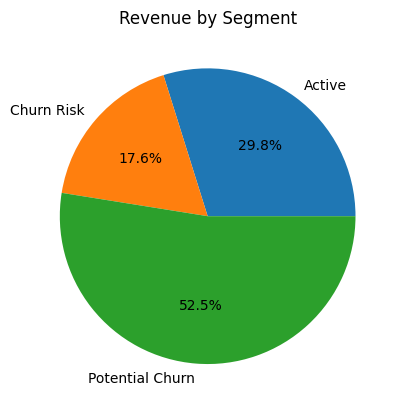

In [113]:
segment_rev=rfm.groupby('Segment')['Monetary'].sum()
segment_rev.plot(kind='pie',autopct='%1.1f%%')
plt.title('Revenue by Segment')
plt.ylabel('')
plt.show()

In [121]:
customer_month=df.groupby(['Customer ID','Month']).size().reset_index(name='Orders')
customer_month.head()


,Customer ID,Month,Orders
0,1,7,1
1,2,3,1
2,2,11,1
3,3,1,1
4,3,5,2


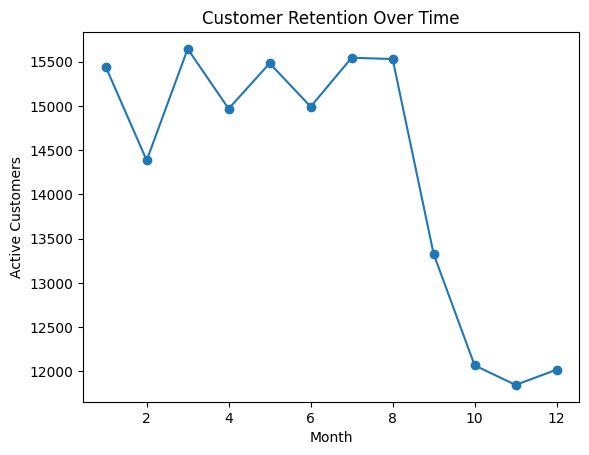

In [116]:
retention = customer_month.groupby('Month')['Customer ID'].nunique()
retention.plot(kind='line',marker='o')
plt.title('Customer Retention Over Time')
plt.xlabel('Month')
plt.ylabel('Active Customers')
plt.show()